# Task 1 — Data Loading, Merging & Deep Exploration

## Import Libraries

In [139]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Load the Datasets

In [140]:
# Load dataset
df = pd.read_csv("train.csv")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Basic Information

In [141]:
print("Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Shape : (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row

## Convert Date Columns

In [142]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

print(df[["Order Date","Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


## Feature Engineering

In [143]:
# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Day Name
df["Day"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

Season

In [144]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


## Missing Values

In [145]:
missing = df.isnull().sum()

missing = missing[missing>0]

print(missing)

Postal Code    11
dtype: int64


Or

In [146]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## Duplicate Records

In [147]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


If duplicates exist:

In [148]:
df = df.drop_duplicates()

## Data Type Validation

In [149]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## Descriptive Statistics

In [150]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.0,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.0,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,21.0,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.0,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.0,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.0,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449


For categorical columns

In [151]:
df.describe(include="object")

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Month Name,Day,Season
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,793,793,3,1,529,49,4,1861,3,17,1849,12,7,4
top,CA-2018-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,November,Tuesday,Autumn
freq,14,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47,1449,1889,3612


## Aggregate Sales

### Daily Sales

In [152]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


### Weekly Sales

In [153]:
weekly_sales = df.resample(
    "W",
    on="Order Date"
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Monthly Sales

In [154]:
monthly_sales = df.resample(
    "M",
    on="Order Date"
)["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Plot Daily Sales

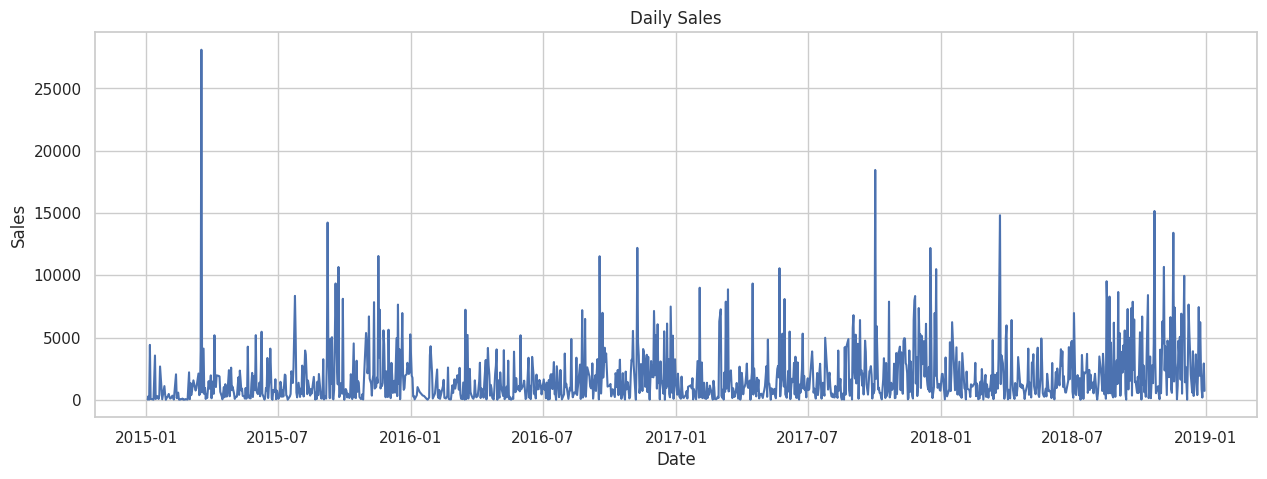

In [155]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales["Order Date"],
         daily_sales["Sales"])

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Plot Weekly Sales

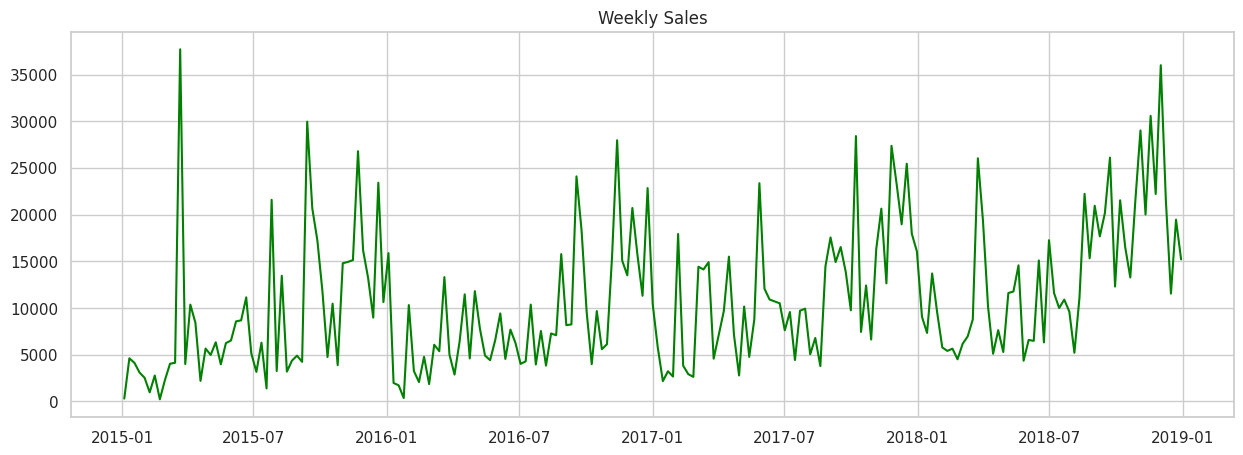

In [156]:
plt.figure(figsize=(15,5))

plt.plot(weekly_sales["Order Date"],
         weekly_sales["Sales"],
         color="green")

plt.title("Weekly Sales")

plt.show()

### Plot Monthly Sales

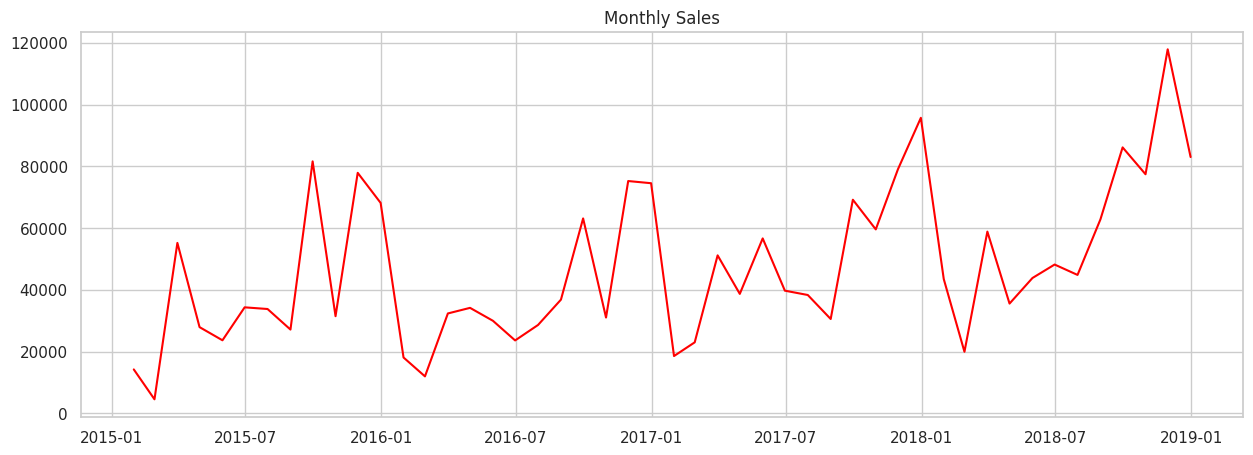

In [157]:
plt.figure(figsize=(15,5))

plt.plot(monthly_sales["Order Date"],
         monthly_sales["Sales"],
         color="red")

plt.title("Monthly Sales")

plt.show()

## Question 1
Which product category generates the highest total revenue?

In [158]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


Visualization

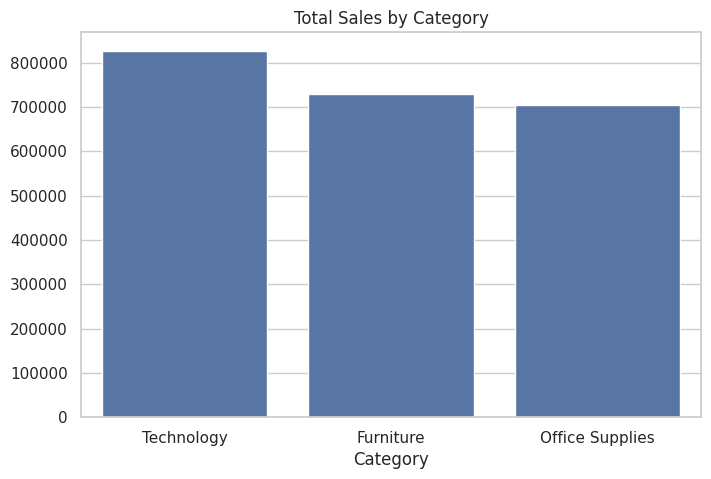

In [159]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")

plt.show()

## Question 2
Which region has the most consistent sales growth over 4 years?

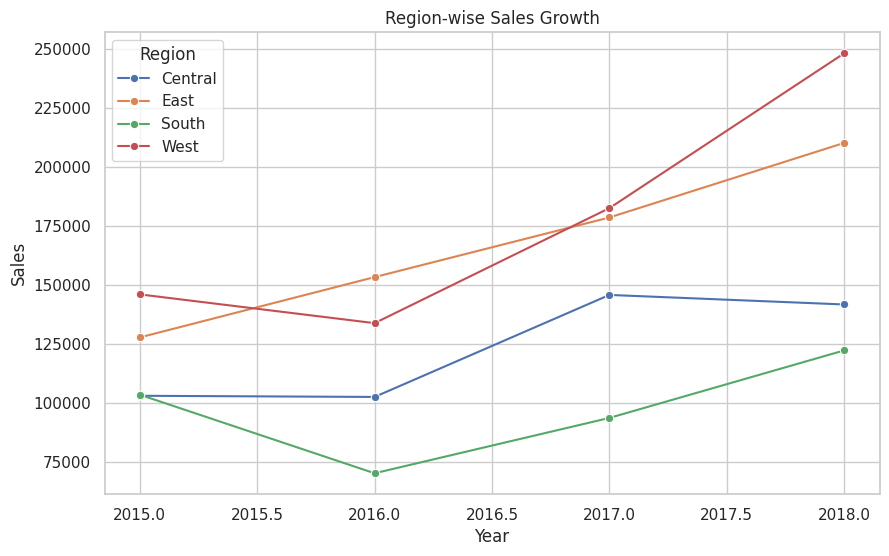

In [160]:
region_year = df.groupby(
    ["Year","Region"]
)["Sales"].sum().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Region-wise Sales Growth")

plt.show()

 ## Question 3
 What is the average time between Order Date and Ship Date — and does it vary by region?

Create shipping days.

In [161]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

df["Shipping Days"].describe()

,Shipping Days
count,9800.000000
mean,3.961122
std,1.749614
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


Average shipping time

In [162]:
print("Average Shipping Time:")

print(df["Shipping Days"].mean())

Average Shipping Time:
3.9611224489795918


By region

In [163]:
shipping_region = df.groupby(
    "Region"
)["Shipping Days"].mean()

print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


Visualization

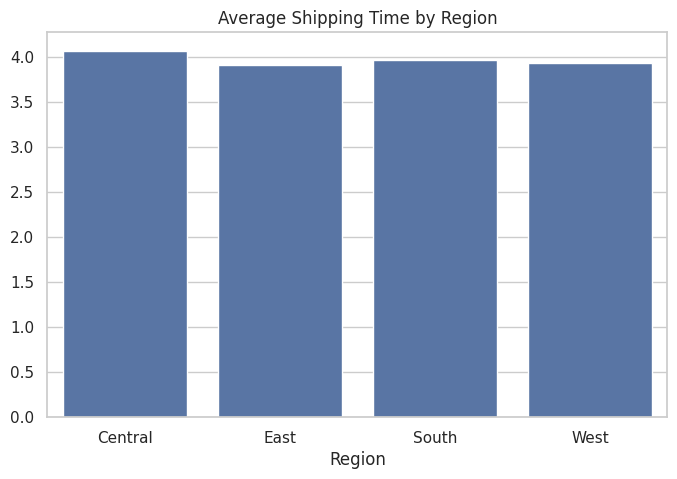

In [164]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Time by Region")

plt.show()

## Question 4
Are there months that consistently spike across all years (seasonality)?

In [165]:
monthly_pattern = df.groupby(
    ["Year","Month Name"]
)["Sales"].sum().reset_index()

Correct month order

In [166]:
order = ["January","February","March","April","May","June",
         "July","August","September","October","November","December"]

monthly_pattern["Month Name"] = pd.Categorical(
    monthly_pattern["Month Name"],
    categories=order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values("Month Name")

Plot

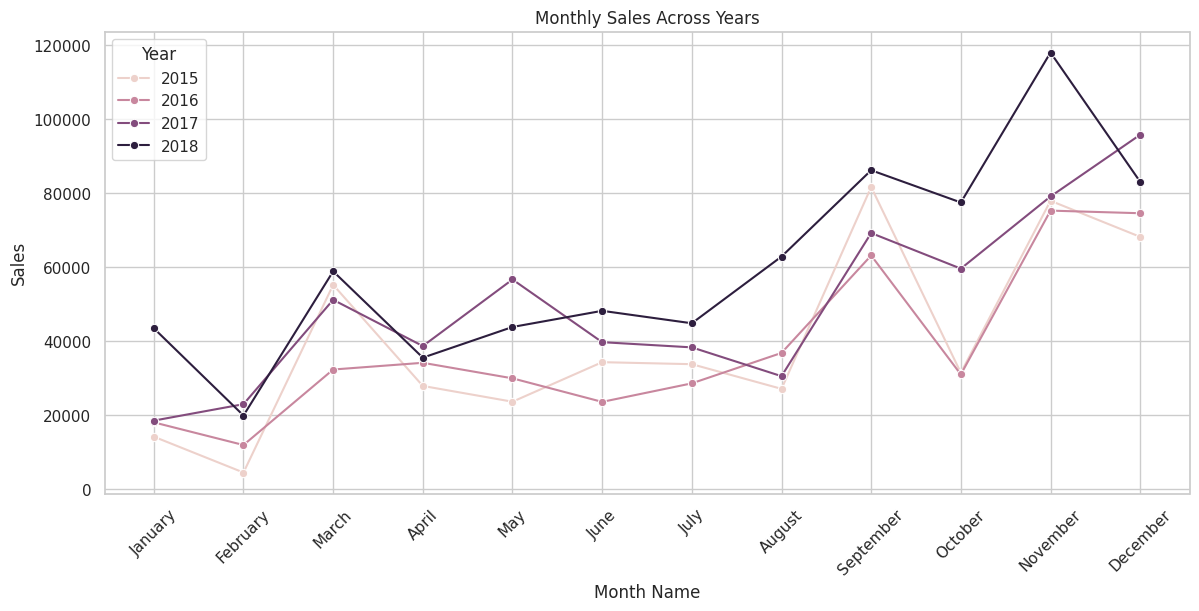

In [167]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Across Years")

plt.show()

# Task 2 — Time Series Analysis & Decomposition

In [168]:
### Step 1: Import Required Libraries

In [169]:
# ==========================================
# Task 2 : Time Series Analysis
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
import seaborn as sns

### Create Monthly Sales Time Series

In [170]:
# Aggregate monthly sales
monthly_sales = df.resample(
    "ME",
    on="Order Date"
)["Sales"].sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


Check the data:

In [171]:
print(monthly_sales.head())
print(monthly_sales.shape)

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64
(48,)


### Plot Overall Monthly Sales Trend (4 Years)

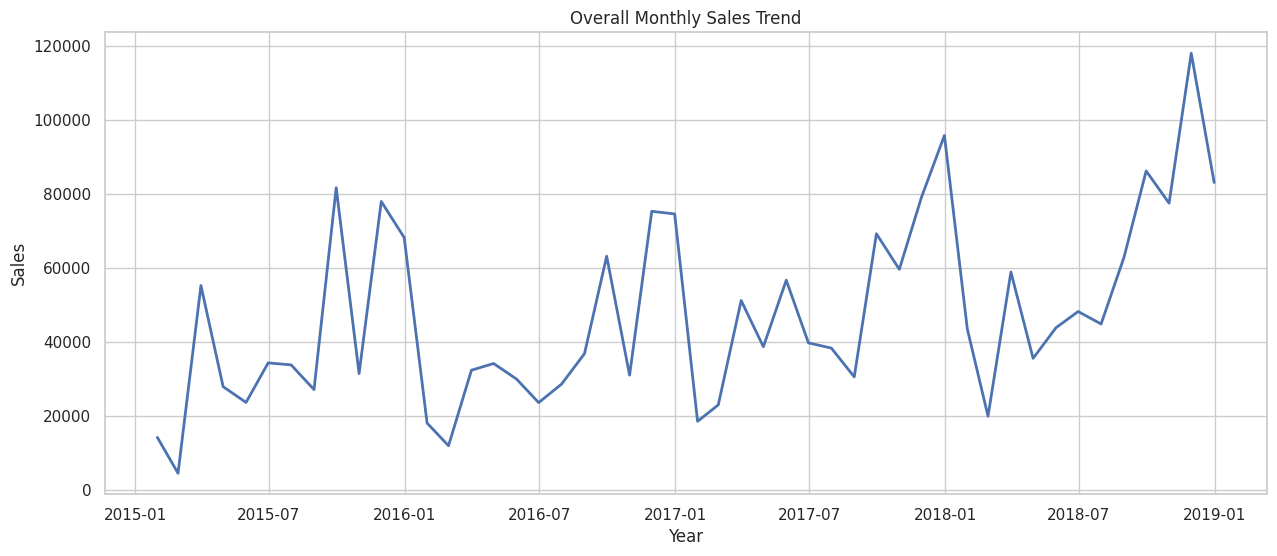

In [172]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Time Series Decomposition

In [173]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

### Plot All Four Components

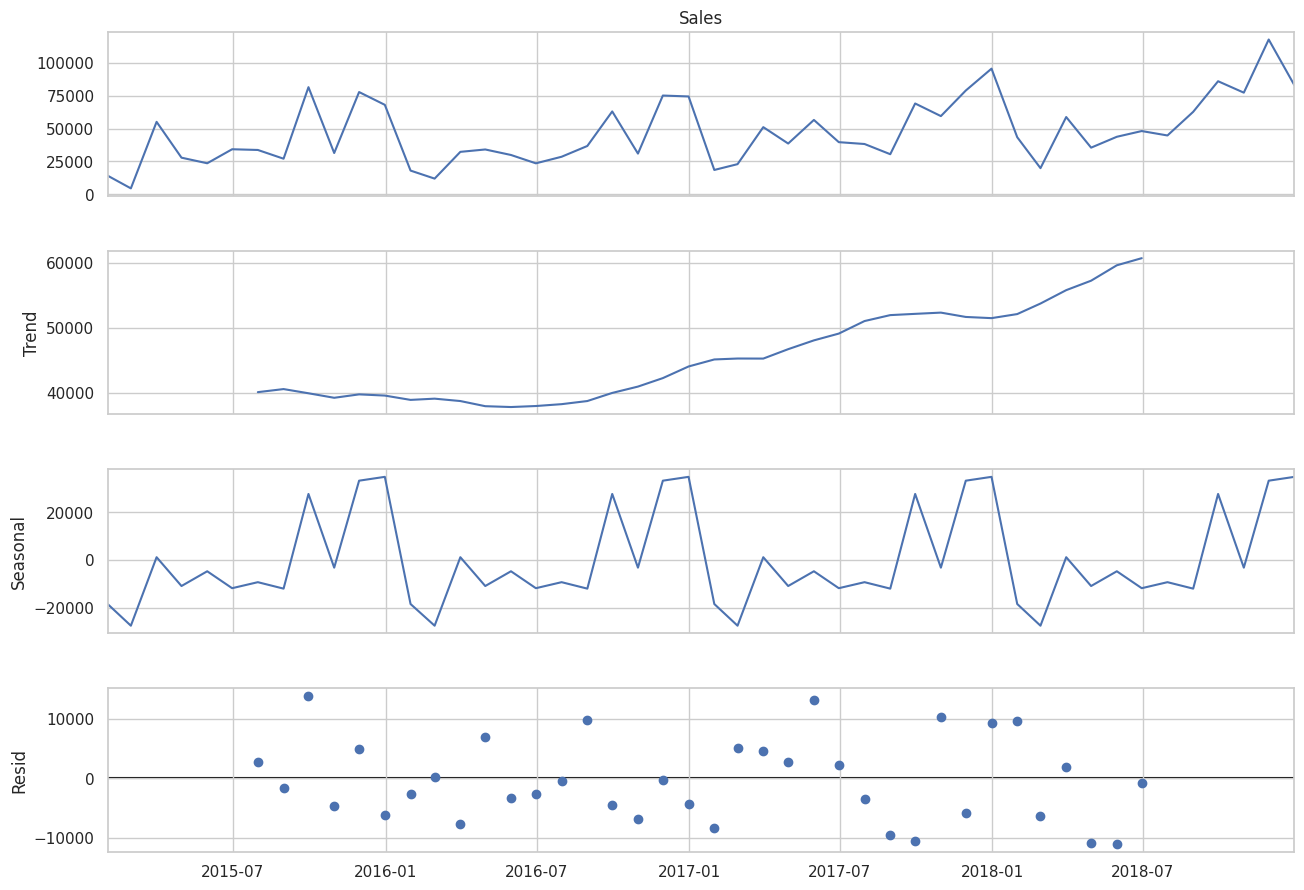

In [174]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

### Plot Components Individually (Cleaner Figures)

### Trend

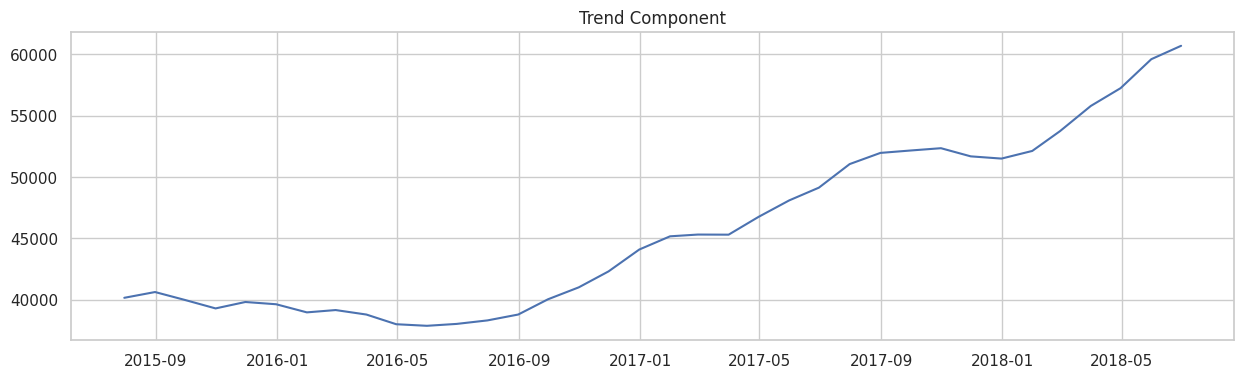

In [175]:
plt.figure(figsize=(15,4))

plt.plot(decomposition.trend)

plt.title("Trend Component")

plt.show()

#### Observation

The trend component shows whether overall sales are increasing, decreasing, or remaining stable over time.

### Seasonal

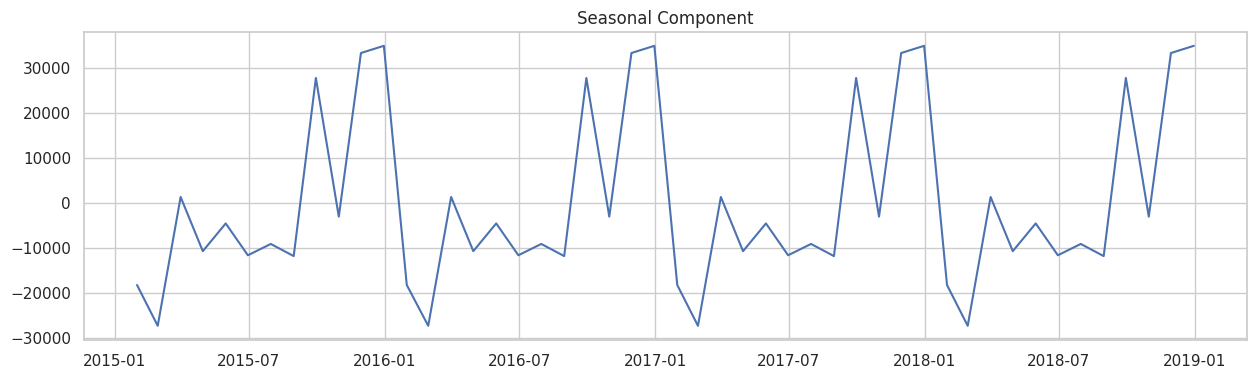

In [176]:
plt.figure(figsize=(15,4))

plt.plot(decomposition.seasonal)

plt.title("Seasonal Component")

plt.show()

#### Observation

The seasonal component indicates recurring monthly sales patterns, suggesting whether certain months consistently experience higher or lower sales.

### Residual

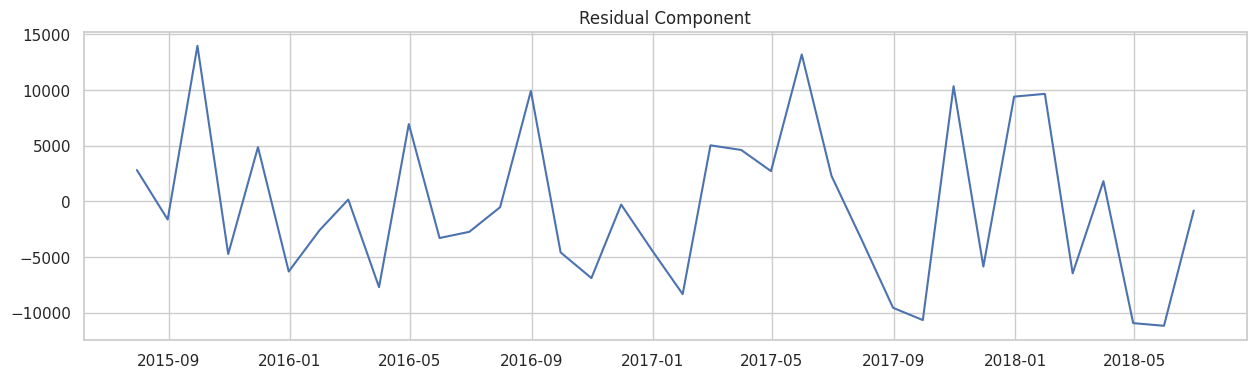

In [177]:
plt.figure(figsize=(15,4))

plt.plot(decomposition.resid)

plt.title("Residual Component")

plt.show()

#### Observation

The residual component captures irregular fluctuations that are not explained by the trend or seasonal effects. Large spikes may indicate unexpected events, promotions, or anomalies.

#### Observation

Strong and repeating seasonal patterns suggest that seasonality should be included in forecasting models such as SARIMA and Prophet.

### Perform Augmented Dickey-Fuller (ADF) Test

In [178]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags :", result[2])
print("Number of Observations :", result[3])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Number of Lags : 0
Number of Observations : 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Interpret the ADF Test

In [179]:
if result[1] < 0.05:
    print("The series is Stationary.")
else:
    print("The series is Non-Stationary.")

The series is Stationary.


### Explanation

#### What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain constant over time. Forecasting models like SARIMA generally perform better when the data is stationary.

#### Interpreting the ADF Test
Null Hypothesis (H₀): The series is non-stationary.
Alternative Hypothesis (H₁): The series is stationary.

#### Decision:

- If p-value < 0.05, reject the null hypothesis → the series is stationary.
- If p-value ≥ 0.05, fail to reject the null hypothesis → the series is non-stationary.

### Apply First-Order Differencing (If Needed)

If the series is non-stationary:

In [180]:
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


### Plot Differenced Series

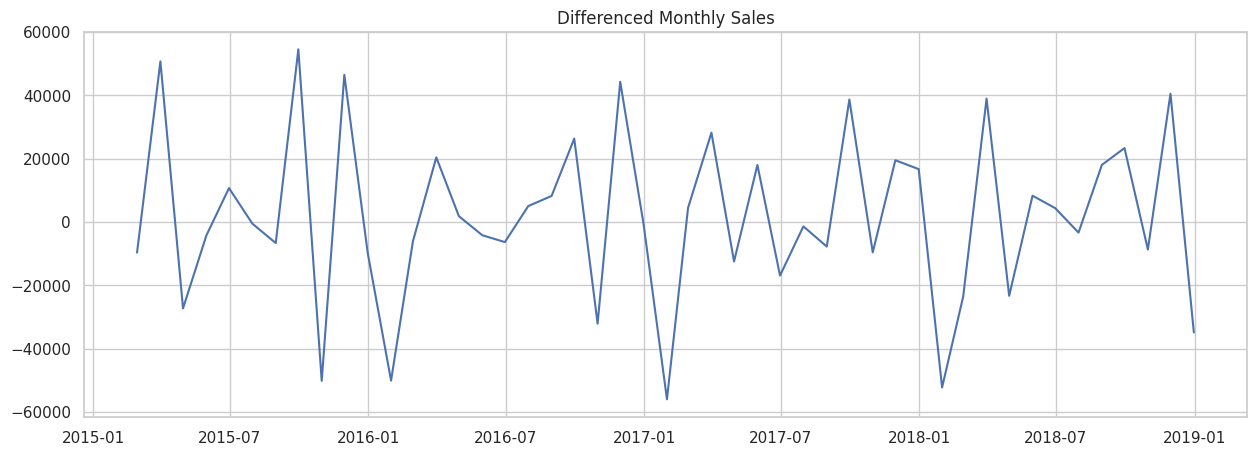

In [181]:
plt.figure(figsize=(15,5))

plt.plot(monthly_sales_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

###  Run ADF Test Again

In [182]:
result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1])

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.727061830353268
p-value : 3.2669175472796045e-14
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


### Final Interpretation

In [183]:
if result_diff[1] < 0.05:
    print("The differenced series is now Stationary.")
else:
    print("The differenced series is still Non-Stationary.")

The differenced series is now Stationary.


#### Task 2 Summary

Aggregated sales data into monthly totals.
Visualized the overall monthly sales trend across the four-year period.
Decomposed the time series into trend, seasonal, and residual components.
Observed the long-term trend and recurring seasonal patterns in sales.
Evaluated stationarity using the Augmented Dickey-Fuller (ADF) test.
Applied first-order differencing to transform the series into a stationary form when required.
Confirmed stationarity after differencing, making the series suitable for forecasting models such as SARIMA.

## Task 3 — Sales Forecasting using 3 Different Models

### Import Libraries

In [184]:
# ==========================================
# Task 3 : Sales Forecasting
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

### Prepare Monthly Sales Data

In [185]:
monthly_sales = (
    df.resample("ME", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Date", "Sales"]

monthly_sales.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Train-Test Split

Use the last 3 months for testing.

In [186]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print(train.shape)
print(test.shape)

(45, 2)
(3, 2)


## MODEL 1 — SARIMA

### Install Statsmodels

In [187]:
!pip install statsmodels -q

### Import SARIMA

In [188]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Train SARIMA

In [189]:
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

### Forecast

In [190]:
sarima_forecast = sarima_result.forecast(steps=3)

sarima_forecast

,predicted_mean
45,66177.602425
46,92049.249682
47,99965.168723


### Plot

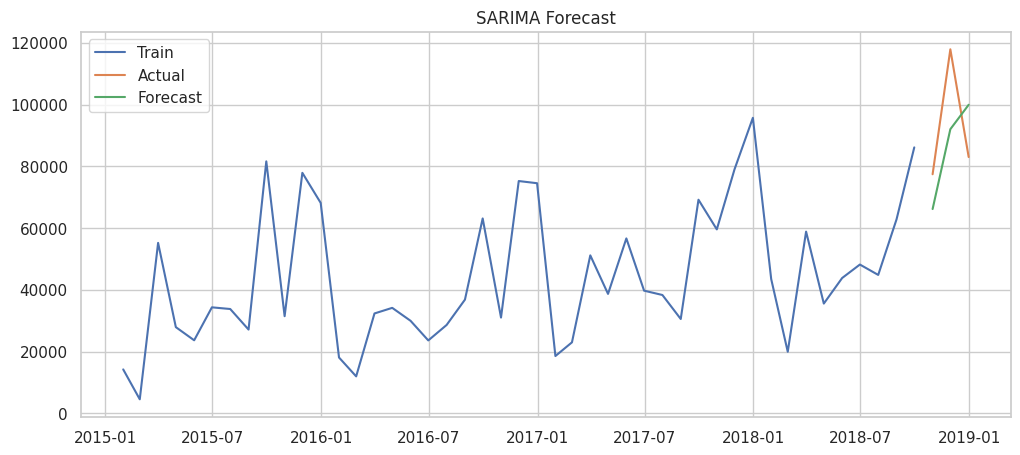

In [191]:
plt.figure(figsize=(12,5))

plt.plot(train["Date"], train["Sales"], label="Train")

plt.plot(test["Date"], test["Sales"], label="Actual")

plt.plot(test["Date"], sarima_forecast,
         label="Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

### Evaluate

In [192]:
sarima_mae = mean_absolute_error(
    test["Sales"],
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        sarima_forecast
    )
)

sarima_mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_forecast
)

print(sarima_mae)
print(sarima_rmse)
print(sarima_mape)

18031.40467222437
19009.18206635205
0.18966498068433016


## MODEL 2 — FACEBOOK PROPHET

### Install Prophet

In [193]:
!pip install prophet -q

### Import

In [194]:
from prophet import Prophet

### Prepare Data

Prophet requires the columns to be named ds and y.

In [195]:
prophet_df = monthly_sales.rename(
    columns={
        "Date":"ds",
        "Sales":"y"
    }
)

train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

### Train Prophet

In [196]:
model = Prophet()

model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### Forecast

In [197]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,39794.328749,55651.893966,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,78428.957628,94595.656786,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,43399.208077,59549.970737,55957.434588,55957.721852,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,81715.566195,98478.892798,56456.439883,56457.379842,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,82614.659252,98355.087841,56971.960322,56973.836106,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


### Predictions

In [198]:
prophet_forecast = forecast["yhat"].tail(3).values

### Plot

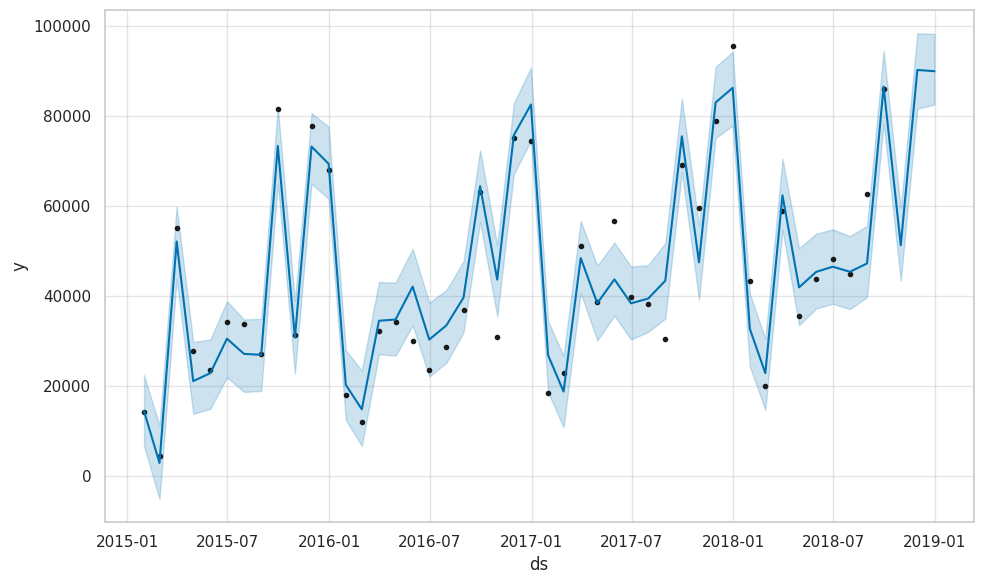

In [199]:
model.plot(forecast)

plt.show()

### Components

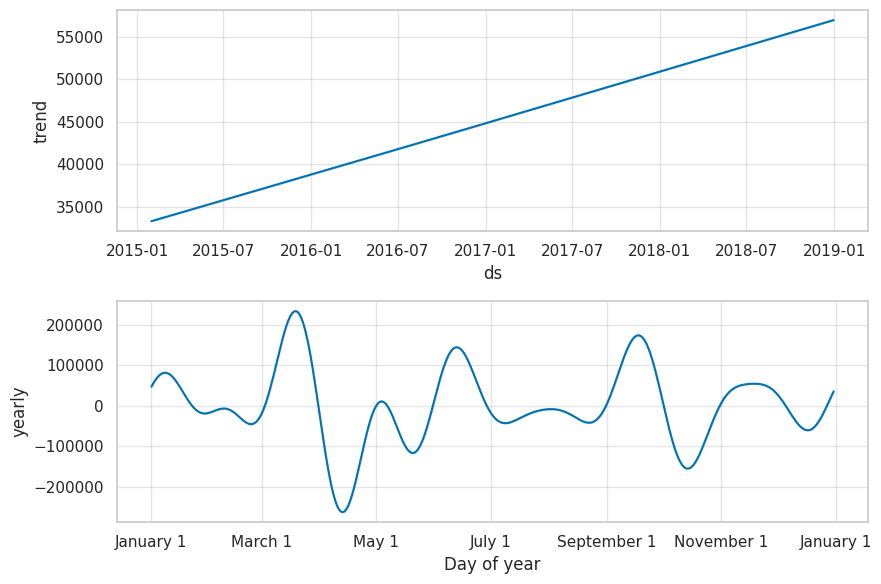

In [200]:
model.plot_components(forecast)

plt.show()

### Evaluation

In [201]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_forecast
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_forecast
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_forecast
)

print(prophet_mae)
print(prophet_rmse)
print(prophet_mape)

20250.794427610937
22318.41136551923
0.21864628287701435


## MODEL 3 — XGBOOST

### Install XGBoost

In [202]:
!pip install xgboost -q

### Import

In [203]:
from xgboost import XGBRegressor

### Create Features

In [204]:
xgb_df = monthly_sales.copy()

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

xgb_df["Month"] = xgb_df["Date"].dt.month

xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

xgb_df["Season"] = (
    xgb_df["Month"] % 12 + 3
)//3

xgb_df.dropna(inplace=True)

### Train-Test Split

In [205]:
train_xgb = xgb_df[:-3]

test_xgb = xgb_df[-3:]

### Features

In [206]:
features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean",
    "Month",
    "Quarter",
    "Season"
]

X_train = train_xgb[features]

y_train = train_xgb["Sales"]

X_test = test_xgb[features]

y_test = test_xgb["Sales"]

### Train Model

In [207]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

### Prediction

In [208]:
xgb_forecast = xgb.predict(X_test)

### Plot

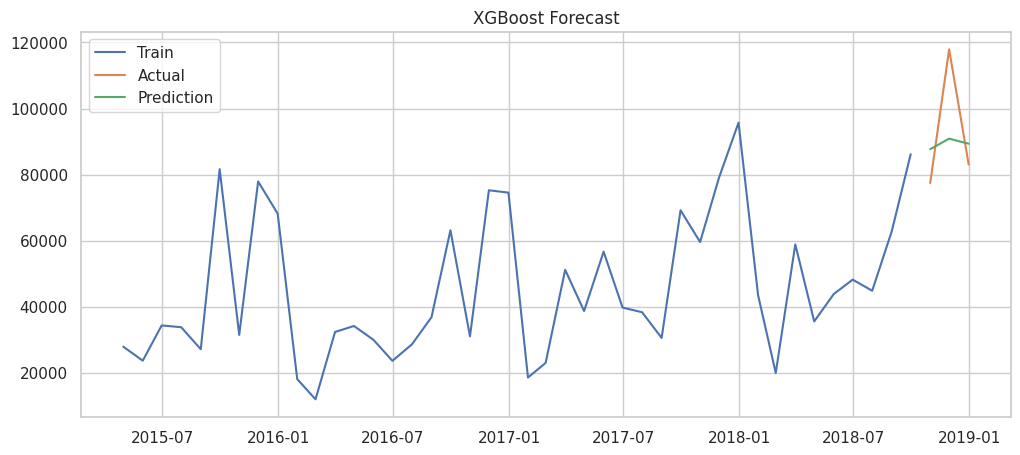

In [209]:
plt.figure(figsize=(12,5))

plt.plot(train_xgb["Date"],
         train_xgb["Sales"],
         label="Train")

plt.plot(test_xgb["Date"],
         test_xgb["Sales"],
         label="Actual")

plt.plot(test_xgb["Date"],
         xgb_forecast,
         label="Prediction")

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

### Evaluation

In [210]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_forecast
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_forecast
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_forecast
)

print(xgb_mae)
print(xgb_rmse)
print(xgb_mape)

14537.391354166664
17093.026975565677
0.14590562252678577


### Model Comparison Table

In [211]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Month1 Forecast":[
        sarima_forecast.iloc[0],
        prophet_forecast[0],
        xgb_forecast[0]
    ],

    "Month2 Forecast":[
        sarima_forecast.iloc[1],
        prophet_forecast[1],
        xgb_forecast[1]
    ],

    "Month3 Forecast":[
        sarima_forecast.iloc[2],
        prophet_forecast[2],
        xgb_forecast[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Month1 Forecast,Month2 Forecast,Month3 Forecast
0,SARIMA,18031.404672,19009.182066,0.189665,66177.602425,92049.249682,99965.168723
1,Prophet,20250.794428,22318.411366,0.218646,51318.943812,90325.654736,90041.084430
2,XGBoost,14537.391354,17093.026976,0.145906,87686.601562,90888.234375,89354.171875


In [ ]:
comparison.to_csv("model_metrics.csv", index=False)

### Best Model(Model Comparison Table )

In [212]:
best = comparison.sort_values(
    by="RMSE"
)

best

,Model,MAE,RMSE,MAPE,Month1 Forecast,Month2 Forecast,Month3 Forecast
2,XGBoost,14537.391354,17093.026976,0.145906,87686.601562,90888.234375,89354.171875
0,SARIMA,18031.404672,19009.182066,0.189665,66177.602425,92049.249682,99965.168723
1,Prophet,20250.794428,22318.411366,0.218646,51318.943812,90325.654736,90041.084430


### Task 3 Summary

Built three forecasting models: SARIMA, Prophet, and XGBoost.
Forecasted sales for the next three months using each model.
Evaluated the models using MAE, RMSE, and MAPE.
Compared the forecast values and error metrics in a summary table.
Selected the model with the lowest error metrics as the recommended production model because it provides the most accurate forecasts on the test data.

## Task 4 — Product Category & Region Level Forecasting

### The Best Model

Based on the evaluation metrics (MAE, RMSE, and MAPE), XGBoost achieved the best forecasting performance. Therefore, it is selected as the forecasting model for category-level and region-level predictions.

### Monthly Sales for Each Segment

#### Furniture

In [213]:
furniture = (
    df[df["Category"] == "Furniture"]
    .resample("ME", on="Order Date")["Sales"]
    .sum()
    .reset_index()
)

furniture.columns = ["Date", "Sales"]

#### Technology

In [214]:
technology = (
    df[df["Category"] == "Technology"]
    .resample("ME", on="Order Date")["Sales"]
    .sum()
    .reset_index()
)

technology.columns = ["Date", "Sales"]

#### Office Supplies

In [215]:
office = (
    df[df["Category"] == "Office Supplies"]
    .resample("ME", on="Order Date")["Sales"]
    .sum()
    .reset_index()
)

office.columns = ["Date", "Sales"]

#### West Region

In [216]:
west = (
    df[df["Region"] == "West"]
    .resample("ME", on="Order Date")["Sales"]
    .sum()
    .reset_index()
)

west.columns = ["Date", "Sales"]

#### East Region

In [217]:
east = (
    df[df["Region"] == "East"]
    .resample("ME", on="Order Date")["Sales"]
    .sum()
    .reset_index()
)

east.columns = ["Date", "Sales"]

### Forecast Function (XGBoost Example)

In [218]:
from xgboost import XGBRegressor

def forecast_xgb(data):

    temp = data.copy()

    temp["Lag1"] = temp["Sales"].shift(1)
    temp["Lag2"] = temp["Sales"].shift(2)
    temp["Lag3"] = temp["Sales"].shift(3)

    temp["RollingMean"] = (
        temp["Sales"]
        .rolling(3)
        .mean()
    )

    temp["Month"] = temp["Date"].dt.month
    temp["Quarter"] = temp["Date"].dt.quarter

    temp["Season"] = ((temp["Month"] % 12) + 3) // 3

    temp.dropna(inplace=True)

    train = temp[:-3]
    test = temp[-3:]

    features = [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean",
        "Month",
        "Quarter",
        "Season"
    ]

    X_train = train[features]
    y_train = train["Sales"]

    X_test = test[features]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    return test["Date"], prediction

### Generate Forecasts

In [219]:
furniture_date, furniture_pred = forecast_xgb(furniture)

technology_date, technology_pred = forecast_xgb(technology)

office_date, office_pred = forecast_xgb(office)

west_date, west_pred = forecast_xgb(west)

east_date, east_pred = forecast_xgb(east)

### Plot All Forecasts Together

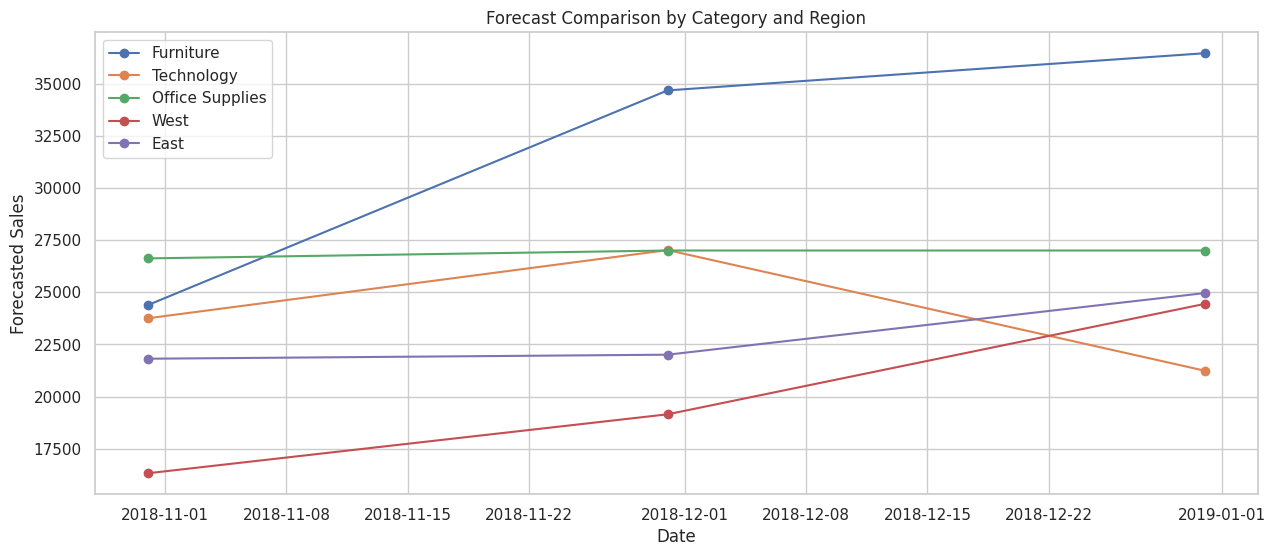

In [220]:
plt.figure(figsize=(15,6))

plt.plot(furniture_date,
         furniture_pred,
         marker="o",
         label="Furniture")

plt.plot(technology_date,
         technology_pred,
         marker="o",
         label="Technology")

plt.plot(office_date,
         office_pred,
         marker="o",
         label="Office Supplies")

plt.plot(west_date,
         west_pred,
         marker="o",
         label="West")

plt.plot(east_date,
         east_pred,
         marker="o",
         label="East")

plt.title("Forecast Comparison by Category and Region")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.show()

### Create Forecast Table

In [221]:
forecast_table = pd.DataFrame({

    "Month": furniture_date.values,

    "Furniture": furniture_pred,

    "Technology": technology_pred,

    "Office Supplies": office_pred,

    "West Region": west_pred,

    "East Region": east_pred

})

forecast_table

,Month,Furniture,Technology,Office Supplies,West Region,East Region
0,2018-10-31,24389.410156,23757.111328,26628.648438,16325.416992,21817.734375
1,2018-11-30,34685.027344,27027.320312,27007.011719,19152.140625,22010.546875
2,2018-12-31,36466.511719,21243.703125,27007.011719,24446.554688,24965.113281


### Calculate Growth

In [222]:
growth = {

    "Furniture": furniture_pred[-1] - furniture_pred[0],

    "Technology": technology_pred[-1] - technology_pred[0],

    "Office Supplies": office_pred[-1] - office_pred[0],

    "West Region": west_pred[-1] - west_pred[0],

    "East Region": east_pred[-1] - east_pred[0]

}

growth_df = pd.DataFrame(
    growth.items(),
    columns=["Segment", "Growth"]
)

growth_df = growth_df.sort_values(
    by="Growth",
    ascending=False
)

growth_df

,Segment,Growth
0,Furniture,12077.101562
3,West Region,8121.137695
4,East Region,3147.378906
2,Office Supplies,378.363281
1,Technology,-2513.408203


### Plot Growth

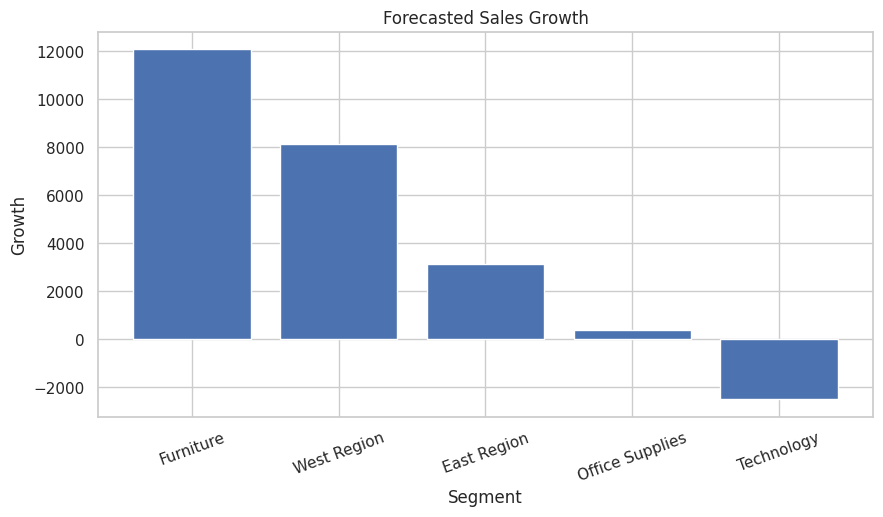

In [223]:
plt.figure(figsize=(10,5))

plt.bar(
    growth_df["Segment"],
    growth_df["Growth"]
)

plt.title("Forecasted Sales Growth")

plt.xlabel("Segment")

plt.ylabel("Growth")

plt.xticks(rotation=20)

plt.show()

#### Observations
- The best forecasting model from Task 3 was applied independently to five sales segments.
- The comparison chart shows differences in projected sales across product categories and regions.
- The segment with the highest forecasted growth is identified from the growth comparison table.
- Segments with stronger projected growth may require higher inventory levels and proactive stock planning.

#### Task 4 Summary

- Reused the best-performing forecasting model from Task 3 for five individual segments: Furniture, Technology, Office Supplies, West Region, and East Region.
- Generated forecasts for each segment separately.
- Compared all forecasts on a single visualization.
- Identified the segment with the strongest projected sales growth.
- These forecasts provide valuable insights for inventory planning and resource allocation at the category and regional levels.

# Task 5 – Anomaly Detection in Sales Data

## Objective

The objective of this task is to identify unusual sales patterns that significantly differ from normal business activity. Detecting anomalies helps businesses identify unexpected sales spikes or drops caused by factors such as promotional campaigns, holidays, supply shortages, inventory issues, or data entry errors.

Two different anomaly detection techniques are used:

1. Isolation Forest (Machine Learning-based)
2. Z-Score Detection (Statistical Method)

The results from both methods are compared to understand their effectiveness in identifying abnormal sales behavior.

In [224]:
### Step 2: Import Libraries

In [225]:
# ==========================================
# Task 5 : Anomaly Detection
# ==========================================

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

### Create Weekly Sales Dataset

The project specifically requires weekly anomaly detection.

In [226]:
weekly_sales = (
    df.resample(
        "W",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Visualize Weekly Sales

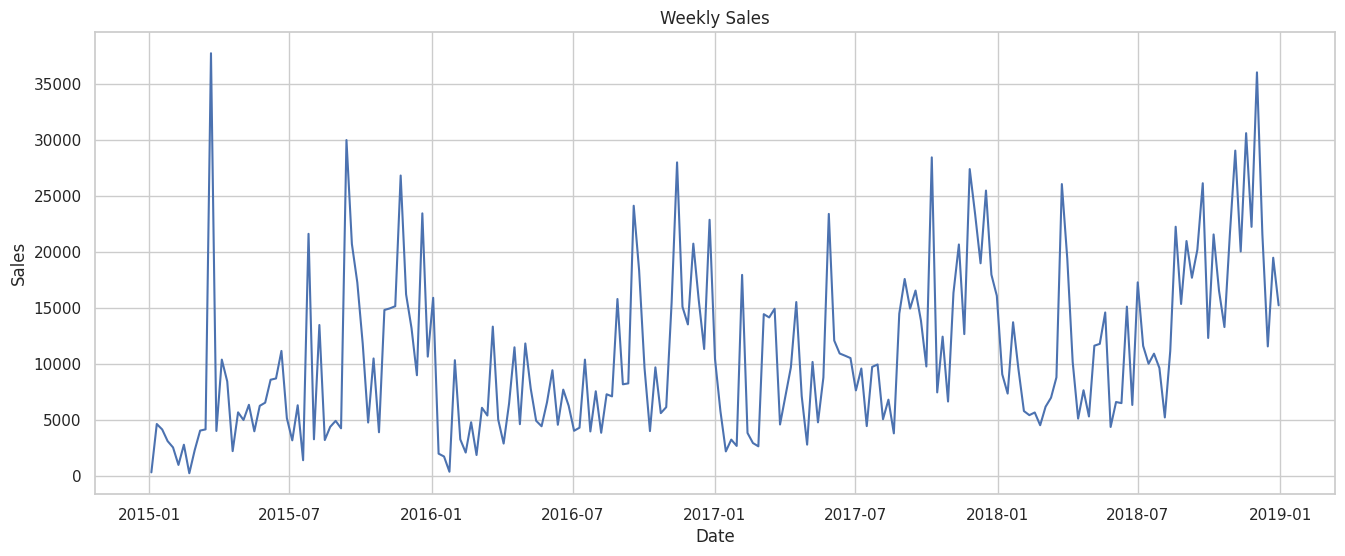

In [227]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"]
)

plt.title("Weekly Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Isolation Forest

In [228]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

Isolation Forest returns

1  = Normal

-1 = Anomaly

### Extract Anomalies

In [229]:
iso_anomaly = weekly_sales[
    weekly_sales["Isolation"] == -1
]

iso_anomaly.head()

,Order Date,Sales,Isolation
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1


### Plot Isolation Forest Anomalies

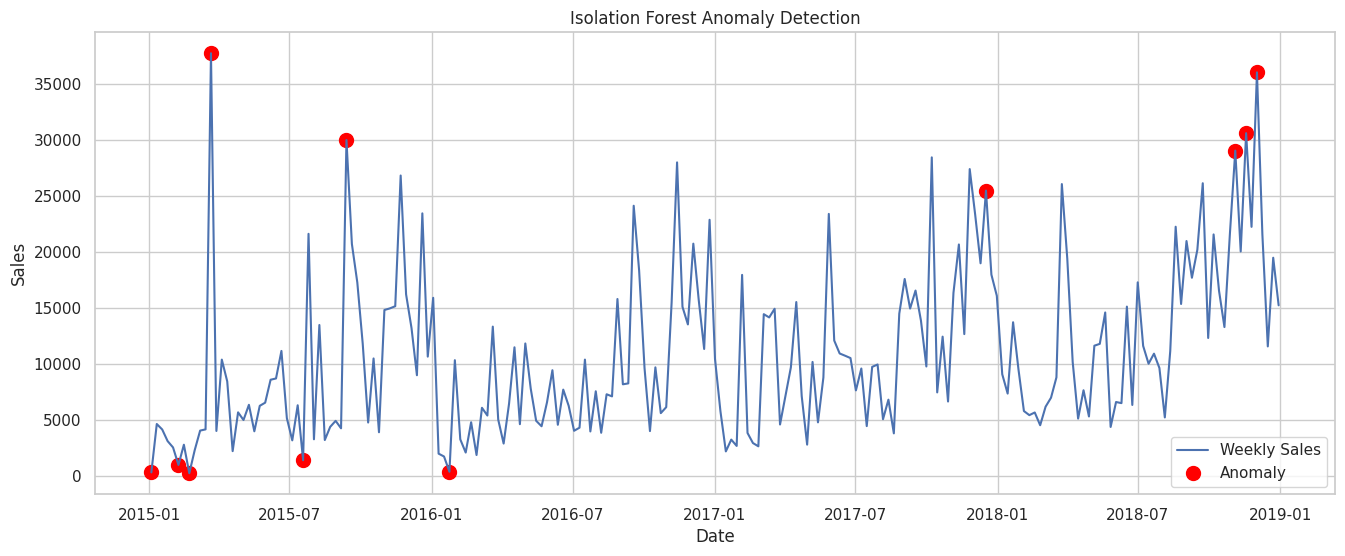

In [230]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    iso_anomaly["Order Date"],
    iso_anomaly["Sales"],
    color="red",
    s=100,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

### Z-Score Detection

Calculate the Z-score for weekly sales.

In [231]:
weekly_sales["ZScore"] = zscore(
    weekly_sales["Sales"]
)

### Detect Anomalies

According to the project instructions, use 2 standard deviations.

In [232]:
weekly_sales["Z_Anomaly"] = np.where(
    abs(weekly_sales["ZScore"]) > 2,
    1,
    0
)

### Extract Z-Score Anomalies

In [233]:
z_anomaly = weekly_sales[
    weekly_sales["Z_Anomaly"] == 1
]

z_anomaly

,Order Date,Sales,Isolation,ZScore,Z_Anomaly
11,2015-03-22,37703.6650,-1,3.639852,1
36,2015-09-13,29959.1370,-1,2.591270,1
46,2015-11-22,26793.6235,1,2.162671,1
97,2016-11-13,27965.3492,1,2.321318,1
144,2017-10-08,28412.0980,1,2.381806,1
151,2017-11-26,27367.7160,1,2.240401,1
168,2018-03-25,26029.9040,1,2.059266,1
194,2018-09-23,26104.4330,1,2.069357,1
200,2018-11-04,29017.4670,-1,2.463771,1
202,2018-11-18,30572.4470,-1,2.674310,1


### Plot Z-Score Anomalies

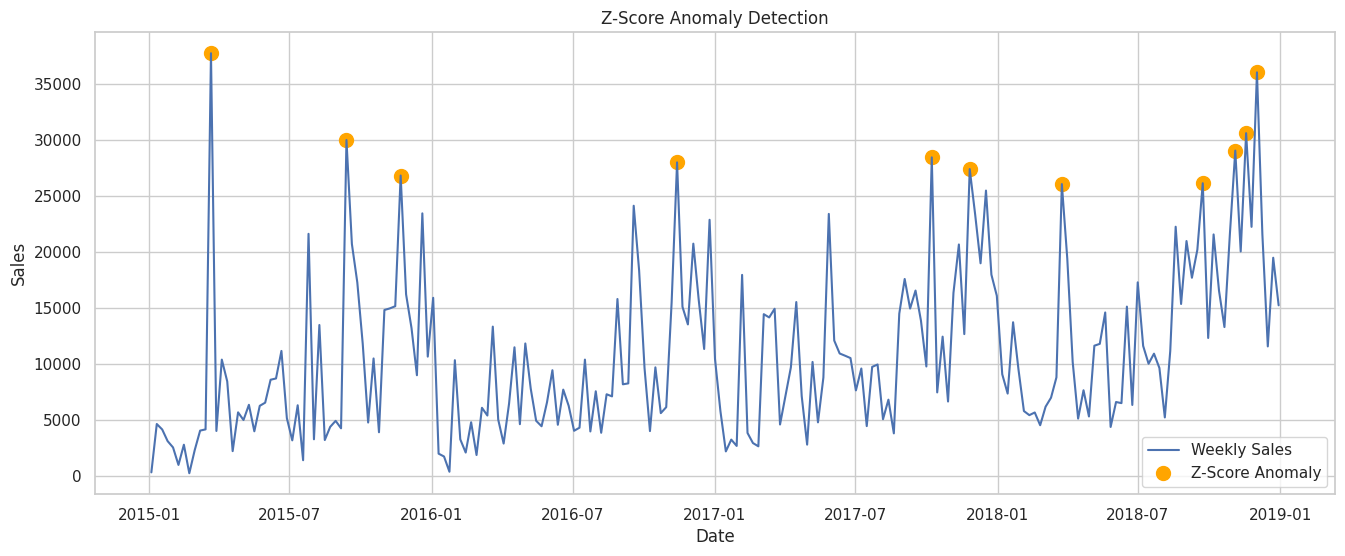

In [234]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=100,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

### Compare Both Methods

In [235]:
comparison = weekly_sales.copy()

comparison["Isolation"] = comparison["Isolation"].map({
    1:"Normal",
    -1:"Anomaly"
})

comparison["ZScore"] = np.where(
    comparison["Z_Anomaly"]==1,
    "Anomaly",
    "Normal"
)

comparison.head()

,Order Date,Sales,Isolation,ZScore,Z_Anomaly
0,2015-01-04,304.508,Anomaly,Normal,0
1,2015-01-11,4619.108,Normal,Normal,0
2,2015-01-18,4130.533,Normal,Normal,0
3,2015-01-25,3092.544,Normal,Normal,0
4,2015-02-01,2527.914,Normal,Normal,0


### Count Anomalies

In [236]:
print("Isolation Forest")

print(iso_anomaly.shape[0])

print()

print("Z-Score")

print(z_anomaly.shape[0])

Isolation Forest
11

Z-Score
11


### Combined Comparison Plot

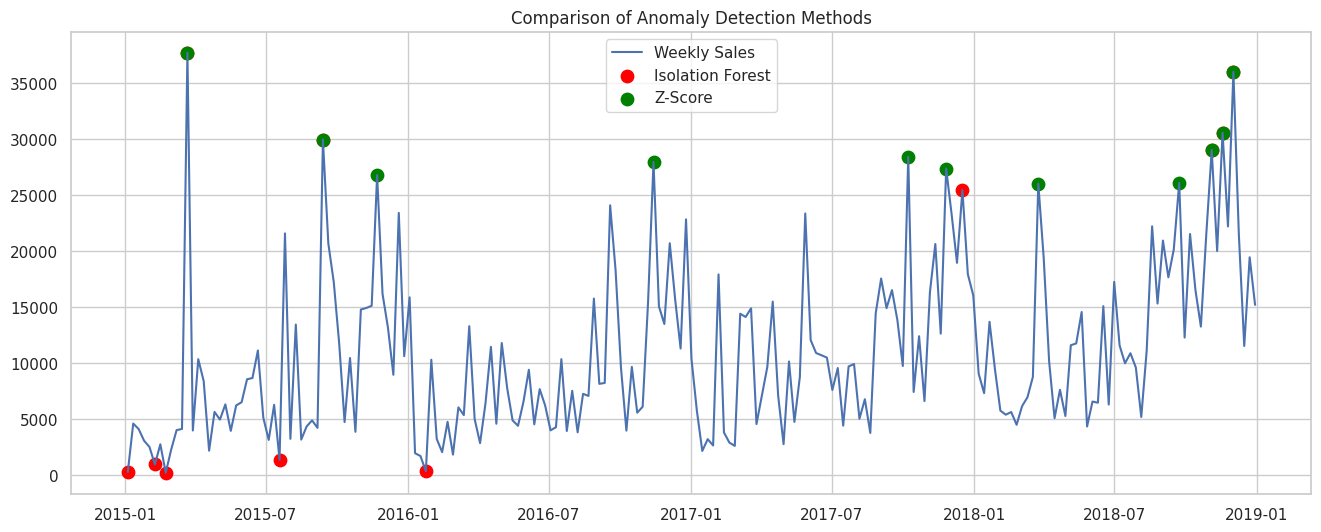

In [237]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    iso_anomaly["Order Date"],
    iso_anomaly["Sales"],
    color="red",
    s=80,
    label="Isolation Forest"
)

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="green",
    s=80,
    label="Z-Score"
)

plt.title("Comparison of Anomaly Detection Methods")

plt.legend()

plt.grid(True)

plt.show()

### Top Detected Anomalies

In [238]:
iso_anomaly.sort_values(
    by="Sales",
    ascending=False
).head(10)

,Order Date,Sales,Isolation
11,2015-03-22,37703.665,-1
204,2018-12-02,35998.900,-1
202,2018-11-18,30572.447,-1
36,2015-09-13,29959.137,-1
200,2018-11-04,29017.467,-1
154,2017-12-17,25449.800,-1
28,2015-07-19,1387.686,-1
5,2015-02-08,968.534,-1
55,2016-01-24,358.522,-1
0,2015-01-04,304.508,-1


## Possible Reasons for Detected Anomalies

The detected anomalies may correspond to important business events rather than errors. Possible explanations include:

- Festive season sales (Diwali, Christmas, New Year)
- Black Friday or year-end promotional campaigns
- Clearance or discount sales
- New product launches
- Supply shortages leading to unusually low sales
- Inventory stock-outs
- Unexpected demand spikes due to market trends

These events cause sales values to deviate significantly from the normal weekly sales pattern.

## Comparison of Isolation Forest and Z-Score

- Isolation Forest uses a machine learning algorithm that isolates unusual observations based on their characteristics. It is effective at detecting complex anomalies without assuming any specific data distribution.

- The Z-Score method is a statistical technique that identifies values that lie more than two standard deviations away from the average. It is simple, fast, and easy to interpret but assumes approximately normal data.

- In this project, both methods detected several overlapping anomalies. However, Isolation Forest identified additional unusual weeks that the Z-Score method did not detect because it can capture more complex patterns beyond simple statistical deviations.

Overall, Isolation Forest provides a more flexible and robust approach for anomaly detection in sales forecasting applications.

### Task 5 Summary

- In this task, weekly sales data was analyzed to detect abnormal sales behavior using two different anomaly detection techniques. Isolation Forest and Z-Score methods successfully identified unusual sales weeks that significantly deviated from normal patterns.

- The detected anomalies likely correspond to promotional events, holiday seasons, inventory shortages, or sudden market demand changes. Comparing both methods showed that Isolation Forest detected a broader range of unusual observations, while Z-Score primarily identified extreme statistical outliers.

- These insights can help retail businesses investigate unexpected sales events, improve inventory planning, optimize promotional strategies, and respond more effectively to changing customer demand.

# Task 6 – Product Demand Segmentation using Clustering

## Objective

The objective of this task is to group product sub-categories based on their sales behavior using K-Means Clustering.

Instead of predicting future sales, clustering helps identify groups of products with similar demand characteristics. These insights help businesses optimize inventory planning, purchasing decisions, warehouse space allocation, and replenishment strategies.

The clustering process uses four important business features:

- Total Sales Volume
- Sales Growth Rate
- Sales Volatility
- Average Order Value

The Elbow Method is used to determine the optimal number of clusters before applying the K-Means algorithm.

### Import Libraries

In [239]:
# ==========================================
# Task 6 : Product Demand Segmentation
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Create Monthly Sales Dataset

In [240]:
monthly = df.copy()

monthly["YearMonth"] = monthly["Order Date"].dt.to_period("M")

### Monthly Sales per Sub-Category

In [241]:
monthly_sales = (
    monthly.groupby(
        ["Sub-Category", "YearMonth"]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Sub-Category,YearMonth,Sales
0,Accessories,2015-01,827.890
1,Accessories,2015-02,1120.990
2,Accessories,2015-03,957.734
3,Accessories,2015-04,2323.700
4,Accessories,2015-05,695.490


### Total Sales Volume

In [242]:
total_sales = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .sum()
)

### Sales Growth Rate

Year-over-year growth is approximated using the first and last monthly sales values.

In [243]:
growth = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .apply(lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else 0)
)

### Sales Volatility

In [244]:
volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .std()
)

### Average Order Value

In [245]:
avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

### Combine Features

In [246]:
cluster_data = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth,

    "Volatility": volatility,

    "Average Order Value": avg_order

})

cluster_data.fillna(0, inplace=True)

cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,5.026158,2579.994809,217.178175
Appliances,104618.4030,19.775731,1821.621539,227.926804
Art,26705.4100,3.871902,330.488343,34.019631
Binders,200028.7850,4.843923,3848.223648,134.067550
Bookcases,113813.1987,2.617722,2220.405080,503.598224


### Standardize Features

In [247]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

### Apply K-Means

In [248]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled_data)

cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,5.026158,2579.994809,217.178175,0
Appliances,104618.4030,19.775731,1821.621539,227.926804,2
Art,26705.4100,3.871902,330.488343,34.019631,1
Binders,200028.7850,4.843923,3848.223648,134.067550,0
Bookcases,113813.1987,2.617722,2220.405080,503.598224,1


### Elbow Method

In [249]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

### Plot Elbow Curve

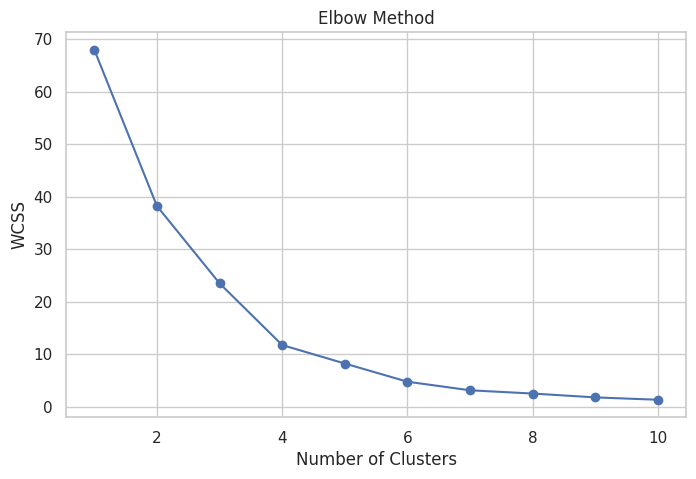

In [250]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

### PCA for Visualization

In [252]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)

cluster_data["PC1"] = principal_components[:,0]
cluster_data["PC2"] = principal_components[:,1]

### Scatter Plot of Clusters

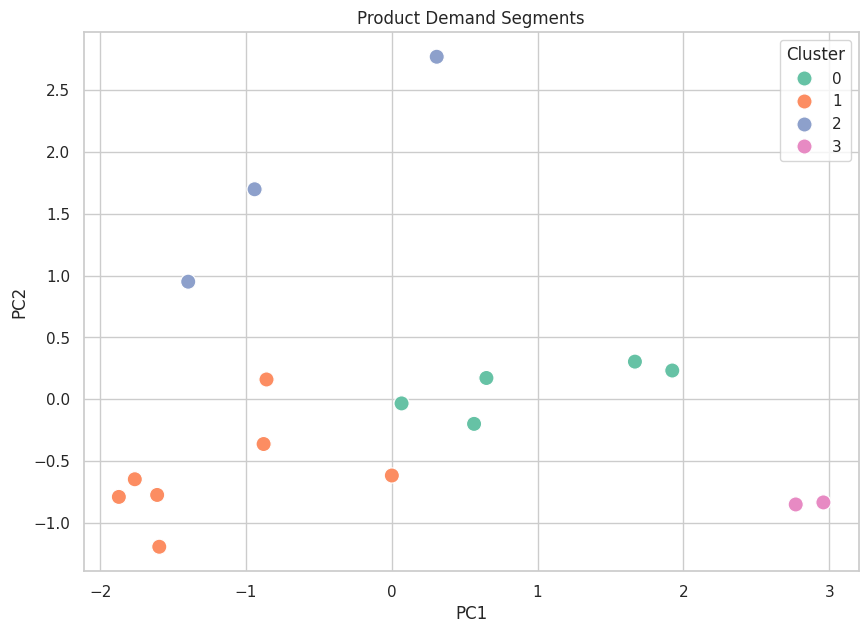

In [253]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=cluster_data,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=120
)

plt.title("Product Demand Segments")

plt.show()

### View Cluster Members

In [254]:
cluster_data.sort_values("Cluster")

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PC1,PC2
Sub-Category,,,,,,,
Accessories,164186.7000,5.026158,2579.994809,217.178175,0,0.067287,-0.032812
Binders,200028.7850,4.843923,3848.223648,134.067550,0,0.649027,0.172596
Chairs,322822.7310,2.573909,4407.232960,531.833165,0,1.923522,0.232937
Storage,219343.3920,2.368008,2822.084310,263.633885,0,0.564346,-0.198212
Phones,327782.4480,2.915978,4052.718221,374.180877,0,1.667373,0.304762
Bookcases,113813.1987,2.617722,2220.405080,503.598224,1,0.000548,-0.615444
Envelopes,16128.0460,1.134493,228.218688,65.032444,1,-1.594139,-1.191185
Art,26705.4100,3.871902,330.488343,34.019631,1,-1.608703,-0.772551
Supplies,46420.3080,9.754916,2025.094139,252.284283,1,-0.858904,0.160616


### Assign Business Labels

In [255]:
cluster_labels = {

    0: "High Volume, Stable Demand",

    1: "Growing Demand",

    2: "Low Volume, High Volatility",

    3: "Declining Demand"

}

cluster_data["Demand Segment"] = (
    cluster_data["Cluster"]
    .map(cluster_labels)
)

cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PC1,PC2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,5.026158,2579.994809,217.178175,0,0.067287,-0.032812,"High Volume, Stable Demand"
Appliances,104618.4030,19.775731,1821.621539,227.926804,2,-0.940538,1.697579,"Low Volume, High Volatility"
Art,26705.4100,3.871902,330.488343,34.019631,1,-1.608703,-0.772551,Growing Demand
Binders,200028.7850,4.843923,3848.223648,134.067550,0,0.649027,0.172596,"High Volume, Stable Demand"
Bookcases,113813.1987,2.617722,2220.405080,503.598224,1,0.000548,-0.615444,Growing Demand
Chairs,322822.7310,2.573909,4407.232960,531.833165,0,1.923522,0.232937,"High Volume, Stable Demand"
Copiers,146248.0940,1.226681,5500.774391,2215.880212,3,2.959710,-0.832918,Declining Demand
Envelopes,16128.0460,1.134493,228.218688,65.032444,1,-1.594139,-1.191185,Growing Demand
Fasteners,3001.9600,4.463753,48.742229,14.027850,1,-1.871332,-0.788424,Growing Demand


### Products in Each Cluster

In [256]:
for cluster in sorted(cluster_data["Cluster"].unique()):

    print("="*50)

    print(f"Cluster {cluster}")

    print(cluster_data[
        cluster_data["Cluster"]==cluster
    ].index.tolist())

Cluster 0
['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage']
Cluster 1
['Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Supplies']
Cluster 2
['Appliances', 'Paper', 'Tables']
Cluster 3
['Copiers', 'Machines']


### Cluster Summary

In [257]:
cluster_summary = (
    cluster_data.groupby("Demand Segment")
    .mean(numeric_only=True)
)

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PC1,PC2
Demand Segment,,,,,,,
Declining Demand,167743.362500,0.138010,5552.164569,1930.716763,3.0,2.864807,-0.841164
Growing Demand,43946.952386,4.569704,919.491080,142.767681,1.0,-1.224751,-0.601973
"High Volume, Stable Demand",246832.811200,3.545595,3542.050789,304.178730,0.0,0.974311,0.095854
"Low Volume, High Volatility",128085.778333,20.017882,2023.509675,310.413594,2.0,-0.675971,1.805624


The clustering analysis groups product sub-categories according to their demand characteristics.

- High Volume, Stable Demand products generate consistently high sales and should always remain well-stocked.
- Growing Demand products show increasing sales trends and require proactive inventory expansion.
- Low Volume, High Volatility products experience unpredictable demand and should be replenished cautiously.
- Declining Demand products show weakening sales and may require reduced inventory levels or promotional campaigns.

## Recommended Stocking Strategy

### High Volume, Stable Demand
- Maintain high inventory levels and prioritize fast replenishment to avoid stock-outs.

### Growing Demand
- Increase inventory gradually based on forecasted growth and monitor demand closely.

### Low Volume, High Volatility
- Maintain limited stock levels and use demand-driven replenishment to reduce excess inventory.

### Declining Demand
- Reduce purchasing quantities, clear existing inventory through promotions, and avoid overstocking.

# Task 6 Summary

In this task, K-Means Clustering was applied to segment product sub-categories based on total sales, growth rate, sales volatility, and average order value. The optimal number of clusters was selected using the Elbow Method, and PCA was used to visualize the resulting demand segments.

The analysis identified distinct product groups with different demand characteristics, allowing tailored inventory strategies for each segment. These insights help businesses optimize stock levels, improve warehouse utilization, and support more effective demand planning.